# ML Pipelines: From Excel to Prediction
### ISY503 — Intelligent Systems | Dr. Nandini's Class Demo

> **Goal:** Show a complete ML pipeline using the Titanic dataset — starting from *"what is Python?"* all the way to 3 working classifiers, compared side by side.

**Sections:**
- **P. Python & Google Colab Crash Course** ← start here if you're new to Python
- **0.** Setup & Imports
- **1.** EDA — the Excel mindset
- **2.** Data Cleaning & Feature Engineering
- **3.** Algorithm 1 — Linear Regression (baseline)
- **4.** Algorithm 2 — Decision Tree
- **5.** Algorithm 3 — KNN
- **6.** Comparison Table
- **7.** [Optional] Random Forest
- **8.** [Optional] SVM

---
## Section P — Python & Google Colab Crash Course

### What is Google Colab?

Google Colab is a **free coding environment that runs entirely in your browser** — no installation, no setup, no "it works on my machine" problems.

- You get a real Python environment, hosted on Google's servers
- Every library we need (`pandas`, `sklearn`, `matplotlib`) is already installed
- You can share it like a Google Doc — anyone with the link can open and run it
- Your work is saved automatically to Google Drive

**Why not just use our own laptops?**
- Installing Python + libraries correctly takes 30–60 minutes and something always breaks
- On Colab: click *Runtime → Run All* and everything runs in seconds
- For ML with large datasets, Colab also gives you access to free GPUs

**How to run a cell:**
- Click the ▶ button on the left of any code cell, OR
- Press `Shift + Enter` to run and move to the next cell
- Press `Ctrl + Enter` (Windows) / `Cmd + Enter` (Mac) to run without moving

> ⚠️ Run cells **top to bottom** — later cells depend on earlier ones.

### P.1 — Your First Python Command: `print()`

`print()` displays something on the screen. That's it. It's the "say out loud" command.

Run the cell below — click ▶ or press `Shift + Enter`.

In [33]:
print('Hello, world!')
print('I am running Python on Google Colab.')
print('No installation. No setup. Just this.')

Hello, world!
I am running Python on Google Colab.
No installation. No setup. Just this.


### P.2 — Variables and Basic Math

A **variable** is just a named box that holds a value. You create one with `=`.

Python supports all the math operations you'd expect: `+`, `-`, `*`, `/`, `**` (power).

In [34]:
# Storing values in variables
name = 'Titanic'
year = 1912
passengers = 891
survival_rate = 0.384

print('Ship:', name)
print('Year:', year)
print('Passengers in dataset:', passengers)
print('Survival rate:', survival_rate)

Ship: Titanic
Year: 1912
Passengers in dataset: 891
Survival rate: 0.384


In [35]:
# Basic math — Python as a calculator
a = 100
b = 37

print('Addition:       ', a + b)
print('Subtraction:    ', a - b)
print('Multiplication: ', a * b)
print('Division:       ', a / b)
print('Power (a²):     ', a ** 2)
print('Floor division: ', a // b,  '  ← whole number only, no decimal')
print('Remainder:      ', a % b,   '  ← what\'s left over after dividing')

Addition:        137
Subtraction:     63
Multiplication:  3700
Division:        2.7027027027027026
Power (a²):      10000
Floor division:  2   ← whole number only, no decimal
Remainder:       26   ← what's left over after dividing


In [36]:
# Variables in calculations
survivors = int(passengers * survival_rate)
died = passengers - survivors

print(f'Out of {passengers} passengers:')
print(f'  Survived: {survivors}')
print(f'  Died:     {died}')
print(f'  Rate:     {survivors / passengers:.1%}')
# The f"..." syntax is called an f-string — it lets you embed variables directly in text

Out of 891 passengers:
  Survived: 342
  Died:     549
  Rate:     38.4%


### P.3 — Importing a Library

Python's real power comes from **libraries** — collections of pre-built tools.

Think of it like a toolbox: Python comes with a basic set of tools built in. Libraries add specialist tools — like adding a power drill to a toolkit that only had a screwdriver.

You **import** a library to make its tools available in your code.

```python
import library_name                        # import the whole library
import library_name as alias              # import with a shorthand name
from library_name import specific_tool   # import just one tool from it
```

The `as` alias is just a nickname — `import pandas as pd` means "import pandas, but I'll call it `pd` so I type less".

In [37]:
# Python's built-in math library — no install needed, just import
import math

print('Square root of 16:  ', math.sqrt(16))
print('Pi:                 ', math.pi)
print('Round up 3.2:       ', math.ceil(3.2))
print('Round down 3.9:     ', math.floor(3.9))

Square root of 16:   4.0
Pi:                  3.141592653589793
Round up 3.2:        4
Round down 3.9:      3


In [38]:
# The random library — useful for demos and reproducibility
import random

random.seed(42)  # 'seed' means: use the same randomness every time — so results are reproducible

print('Random number between 1–10: ', random.randint(1, 10))
print('Random choice from a list:  ', random.choice(['survived', 'died', 'unknown']))

passengers_sample = [23, 45, 12, 67, 34, 55, 8, 90]
random.shuffle(passengers_sample)
print('Shuffled list: ', passengers_sample)

Random number between 1–10:  2
Random choice from a list:   survived
Shuffled list:  [90, 67, 12, 23, 55, 8, 45, 34]


### P.4 — pandas: Working with Tables in Python

**pandas** is the most important library in data science. It gives you `DataFrame` — a table, like an Excel spreadsheet, but in Python.

- Rows = records (one per passenger)
- Columns = features (age, sex, class, fare...)
- You can filter, sort, aggregate, join — everything Excel can do, and more

The convention is `import pandas as pd` — you'll see this in virtually every data science notebook in the world.

In [39]:
import pandas as pd

# Create a small DataFrame manually — like building a spreadsheet
data = {
    'name':     ['Alice', 'Bob', 'Carlos', 'Diana', 'Eve'],
    'age':      [29, 35, 22, 41, 27],
    'class':    [1, 3, 2, 1, 3],
    'survived': [1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
print('Our mini DataFrame:')
print(df)

Our mini DataFrame:
     name  age  class  survived
0   Alice   29      1         1
1     Bob   35      3         0
2  Carlos   22      2         1
3   Diana   41      1         1
4     Eve   27      3         0


In [40]:
# Exploring the DataFrame — these are your first commands to memorise
print('--- Shape (rows, columns) ---')
print(df.shape)

print('\n--- Column names ---')
print(df.columns.tolist())

print('\n--- Data types per column ---')
print(df.dtypes)

print('\n--- Quick stats summary ---')
print(df.describe())

--- Shape (rows, columns) ---
(5, 4)

--- Column names ---
['name', 'age', 'class', 'survived']

--- Data types per column ---
name        object
age          int64
class        int64
survived     int64
dtype: object

--- Quick stats summary ---
             age  class  survived
count   5.000000    5.0  5.000000
mean   30.800000    2.0  0.600000
std     7.362065    1.0  0.547723
min    22.000000    1.0  0.000000
25%    27.000000    1.0  0.000000
50%    29.000000    2.0  1.000000
75%    35.000000    3.0  1.000000
max    41.000000    3.0  1.000000


In [41]:
# Accessing columns and filtering rows

# Single column → like selecting a column in Excel
print('Ages:')
print(df['age'])

print('\nAverage age:', df['age'].mean())
print('Oldest passenger:', df['age'].max())

# Filter rows — like Excel's Filter button
print('\nPassengers who survived:')
print(df[df['survived'] == 1])

print('\nPassengers in 1st class who survived:')
print(df[(df['class'] == 1) & (df['survived'] == 1)])

Ages:
0    29
1    35
2    22
3    41
4    27
Name: age, dtype: int64

Average age: 30.8
Oldest passenger: 41

Passengers who survived:
     name  age  class  survived
0   Alice   29      1         1
2  Carlos   22      2         1
3   Diana   41      1         1

Passengers in 1st class who survived:
    name  age  class  survived
0  Alice   29      1         1
3  Diana   41      1         1


In [42]:
# groupby — the Python equivalent of a pivot table
print('Survival rate by class (like a pivot table):')
print(df.groupby('class')['survived'].mean())

print('\nAverage age by class:')
print(df.groupby('class')['age'].mean().round(1))

Survival rate by class (like a pivot table):
class
1    1.0
2    1.0
3    0.0
Name: survived, dtype: float64

Average age by class:
class
1    35.0
2    22.0
3    31.0
Name: age, dtype: float64


### P.5 — How to Find Help: Documentation & `help()`

You don't need to memorise everything. The best engineers look things up constantly.

**3 ways to get help:**

1. **`help(function)`** — built into Python, shows the documentation right here in the notebook
2. **`?` in Colab** — type `pd.DataFrame?` and press Enter to open the docs sidebar
3. **Official docs** — https://pandas.pydata.org/docs/ (search any function)

Pro tip: Google `"pandas how to [thing you want]"` — Stack Overflow will have the answer.

In [43]:
# See the documentation for a pandas function directly in the notebook
help(df.groupby)

# Note: the output is long — scroll through it to see what arguments it accepts
# The key part is always: Parameters (what goes in) and Returns (what comes out)

Help on method groupby in module pandas.core.frame:

groupby(by=None, axis: 'Axis' = 0, level: 'IndexLabel | None' = None, as_index: 'bool' = True, sort: 'bool' = True, group_keys: 'bool' = True, observed: 'bool' = False, dropna: 'bool' = True) -> 'DataFrameGroupBy' method of pandas.core.frame.DataFrame instance
    Group DataFrame using a mapper or by a Series of columns.

    A groupby operation involves some combination of splitting the
    object, applying a function, and combining the results. This can be
    used to group large amounts of data and compute operations on these
    groups.

    Parameters
    ----------
    by : mapping, function, label, pd.Grouper or list of such
        Used to determine the groups for the groupby.
        If ``by`` is a function, it's called on each value of the object's
        index. If a dict or Series is passed, the Series or dict VALUES
        will be used to determine the groups (the Series' values are first
        aligned; see ``.align()

In [44]:
# Shorter doc check — just the signature and one-line description
# In Colab, you can also just type the function name followed by ? and run the cell:

# df.describe?
# pd.read_csv?

# For now, let's just see what .describe() gives us on the real Titanic data:
import seaborn as sns
titanic = sns.load_dataset('titanic')

print('Real Titanic dataset — statistical summary:')
titanic[['age', 'fare', 'pclass', 'survived']].describe().round(2)

Real Titanic dataset — statistical summary:


,age,fare,pclass,survived
count,714.00,891.00,891.00,891.00
mean,29.70,32.20,2.31,0.38
std,14.53,49.69,0.84,0.49
min,0.42,0.00,1.00,0.00
25%,20.12,7.91,2.00,0.00
50%,28.00,14.45,3.00,0.00
75%,38.00,31.00,3.00,1.00
max,80.00,512.33,3.00,1.00


### ✅ Python Crash Course Complete!

You now know:
- What Google Colab is and how to run cells
- `print()` — display output
- Variables — store any value with `=`
- Math operators — `+`, `-`, `*`, `/`, `**`
- `import` — load a library's tools
- `pandas` basics — DataFrame, columns, filtering, groupby
- How to find documentation with `help()` and `?`

**That's enough Python to follow everything in this notebook.**

Let's build the ML pipeline. ↓

---
## Section 0 — Setup & Imports

This cell loads every library we'll use for the entire notebook.
Run it once — all subsequent sections depend on it.

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## Section 1 — EDA: The Excel Mindset

Before any ML, let's ask: **"What would a pivot table tell us?"**

The Titanic dataset has 891 passengers. We want to predict: **did they survive?** (1 = yes, 0 = no)

Features available: `pclass` (ticket class), `sex`, `age`, `sibsp` (siblings/spouses aboard), `parch` (parents/children aboard), `fare`

In [46]:
# Load the Titanic dataset — no download needed in Colab!
df = sns.load_dataset('titanic')

print(f'Dataset shape: {df.shape}  ({df.shape[0]} passengers, {df.shape[1]} columns)')
print(f'\nTarget: survived — {df["survived"].value_counts().to_dict()}')
print(f'  → {df["survived"].mean():.1%} of passengers survived\n')
df.head()

Dataset shape: (891, 15)  (891 passengers, 15 columns)

Target: survived — {0: 549, 1: 342}
  → 38.4% of passengers survived



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [47]:
# PIVOT TABLE: Survival rate by sex — the most predictive single feature
print('='*50)
print('Survival rate by SEX (like a pivot table):')
print('='*50)
print(df.groupby('sex')['survived'].mean().round(3))

print('\n' + '='*50)
print('Survival rate by TICKET CLASS:')
print('='*50)
print(df.groupby('pclass')['survived'].mean().round(3))

# Age bands
df['age_band'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
print('\n' + '='*50)
print('Survival rate by AGE BAND:')
print('='*50)
print(df.groupby('age_band', observed=True)['survived'].mean().round(3))

Survival rate by SEX (like a pivot table):
sex
female    0.742
male      0.189
Name: survived, dtype: float64

Survival rate by TICKET CLASS:
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64

Survival rate by AGE BAND:
age_band
Child          0.580
Teen           0.429
Young Adult    0.383
Adult          0.400
Senior         0.227
Name: survived, dtype: float64


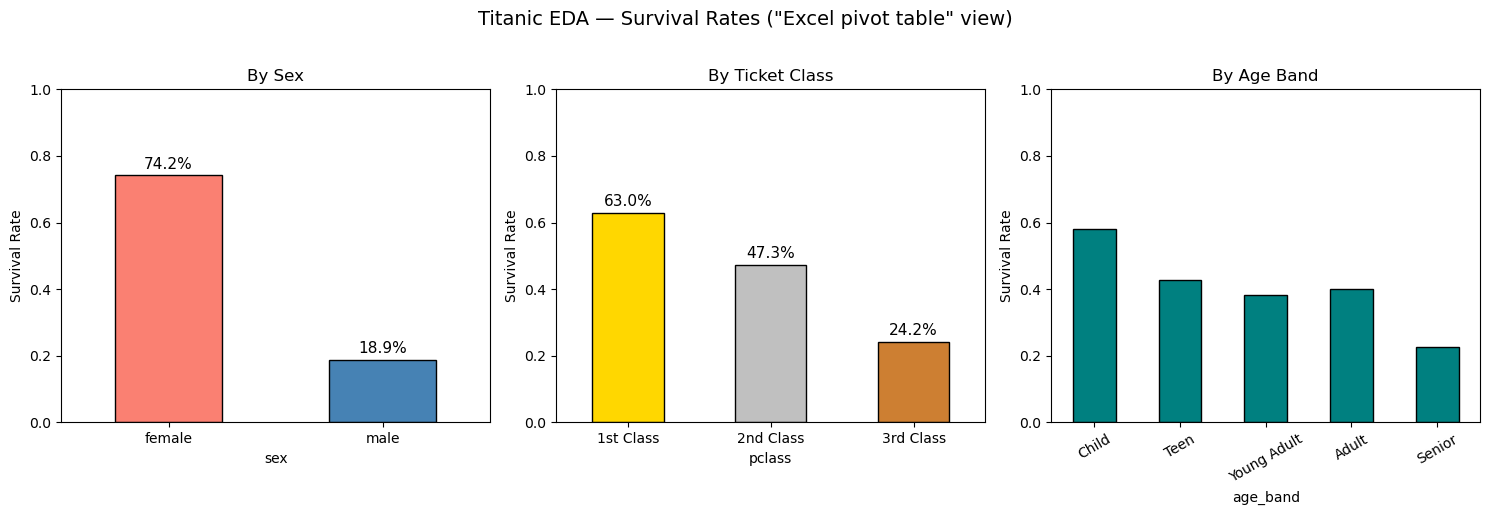


💡 Key insight: Women and 1st-class passengers had significantly higher survival rates.
   But can we PREDICT individual outcomes? That is what ML is for.


In [48]:
# Visualize the pivot-table findings
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Titanic EDA — Survival Rates ("Excel pivot table" view)', fontsize=14, y=1.02)

# Sex
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0],
                                           color=['salmon', 'steelblue'], edgecolor='black')
axes[0].set_title('By Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.1%}', ha='center', fontsize=11)

# Class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1],
                                              color=['gold', 'silver', '#cd7f32'], edgecolor='black')
axes[1].set_title('By Ticket Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.1%}', ha='center', fontsize=11)

# Age band
df.groupby('age_band', observed=True)['survived'].mean().plot(kind='bar', ax=axes[2],
                                                               color='teal', edgecolor='black')
axes[2].set_title('By Age Band')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print('\n💡 Key insight: Women and 1st-class passengers had significantly higher survival rates.')
print('   But can we PREDICT individual outcomes? That is what ML is for.')

---
## Section 2 — Data Cleaning & Feature Engineering

**The suitcase analogy:** Imagine you're packing a suitcase for the algorithm.
- Some items need folding first (encoding text → numbers)
- Some items are missing and you need to estimate them (filling null ages)
- Some items don't fit or aren't useful (drop irrelevant columns)

ML algorithms only understand **numbers** — no text, no nulls.

In [49]:
# Keep only the features we want to use
data = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].copy()

print('Missing values before cleaning:')
print(data.isnull().sum())
print(f'\nTotal missing: {data.isnull().sum().sum()}')

Missing values before cleaning:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

Total missing: 177


In [50]:
# Step 1: Fill missing age with median (a reasonable estimate)
median_age = data['age'].median()
data['age'] = data['age'].fillna(median_age)
print(f'Missing ages filled with median age: {median_age:.0f} years')

# Step 2: Encode sex — algorithms need numbers, not text
# female → 0, male → 1
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])
print(f'Sex encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Step 3: Drop any remaining nulls (fare has a few)
before = len(data)
data = data.dropna()
print(f'Dropped {before - len(data)} rows with remaining nulls')

print(f'\n✅ Clean dataset: {data.shape[0]} passengers, {data.shape[1]} columns')
print('Any nulls left?', data.isnull().sum().sum() == 0)
data.head()

Missing ages filled with median age: 28 years
Sex encoded: {'female': 0, 'male': 1}
Dropped 0 rows with remaining nulls

✅ Clean dataset: 891 passengers, 7 columns
Any nulls left? True


,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500


In [51]:
# Train/test split — 80% train, 20% test
X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train/Test Split (80/20):')
print(f'  Training: {X_train.shape[0]} passengers (the algorithm learns from these)')
print(f'  Testing:  {X_test.shape[0]} passengers  (we check accuracy on these — NEVER shown during training)')
print(f'\nFeatures used: {list(X.columns)}')

Train/Test Split (80/20):
  Training: 712 passengers (the algorithm learns from these)
  Testing:  179 passengers  (we check accuracy on these — NEVER shown during training)

Features used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']


---
## Section 3 — Algorithm 1: Linear Regression (Baseline)

**What it does:** Fits a straight line through the data to predict the output.

**Why start here?** It's the simplest ML algorithm — everyone has seen a trendline in Excel.

**The catch:** Linear Regression predicts **continuous values** (like house prices). We're predicting survival: either 0 or 1. So what happens?

In [52]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_raw = lr.predict(X_test)

print('Sample raw predictions from Linear Regression:')
print(y_pred_raw[:15].round(3))
print(f'\nMin prediction: {y_pred_raw.min():.3f}')
print(f'Max prediction: {y_pred_raw.max():.3f}')
print(f'\n⚠️  Problem: Survival should be 0 or 1, but we get values OUTSIDE [0, 1]')
print('   A prediction of -0.2 or 1.3 makes no sense for "did they survive?"')

Sample raw predictions from Linear Regression:
[0.059 0.261 0.159 0.889 0.668 0.991 0.639 0.101 0.697 0.953 0.365 0.043
 0.501 0.11  0.238]

Min prediction: -0.063
Max prediction: 0.997

⚠️  Problem: Survival should be 0 or 1, but we get values OUTSIDE [0, 1]
   A prediction of -0.2 or 1.3 makes no sense for "did they survive?"


In [53]:
# Workaround: round anything ≥ 0.5 to 1, else 0
y_pred_lr = (y_pred_raw >= 0.5).astype(int)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f'Linear Regression Accuracy (threshold=0.5): {acc_lr:.1%}')
print()
print('Summary:')
print('  ✅ Simple baseline — fast to train, easy to understand')
print('  ❌ Not designed for classification — predicts outside [0,1]')
print('  ❌ No probability output, no confidence score')
print()
print('→ This is exactly WHY classification algorithms were invented.')
print('  Let\'s fix this with a Decision Tree.')

Linear Regression Accuracy (threshold=0.5): 78.2%

Summary:
  ✅ Simple baseline — fast to train, easy to understand
  ❌ Not designed for classification — predicts outside [0,1]
  ❌ No probability output, no confidence score

→ This is exactly WHY classification algorithms were invented.
  Let's fix this with a Decision Tree.


---
## Section 4 — Algorithm 2: Decision Tree

**What it does:** Learns a series of if/else rules from the data — like a flowchart.

**Why it's better for classification:** It only predicts valid classes (0 or 1). No outputs outside the range.

**The superpower:** You can *visualize* the entire decision process. Even non-technical stakeholders can read and verify the rules.

In [54]:
# Train Decision Tree — max_depth=3 keeps it readable
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f'Decision Tree Accuracy: {acc_dt:.1%}')
print(f'Improvement over Linear Regression: {acc_dt - acc_lr:+.1%}')

Decision Tree Accuracy: 79.9%
Improvement over Linear Regression: +1.7%


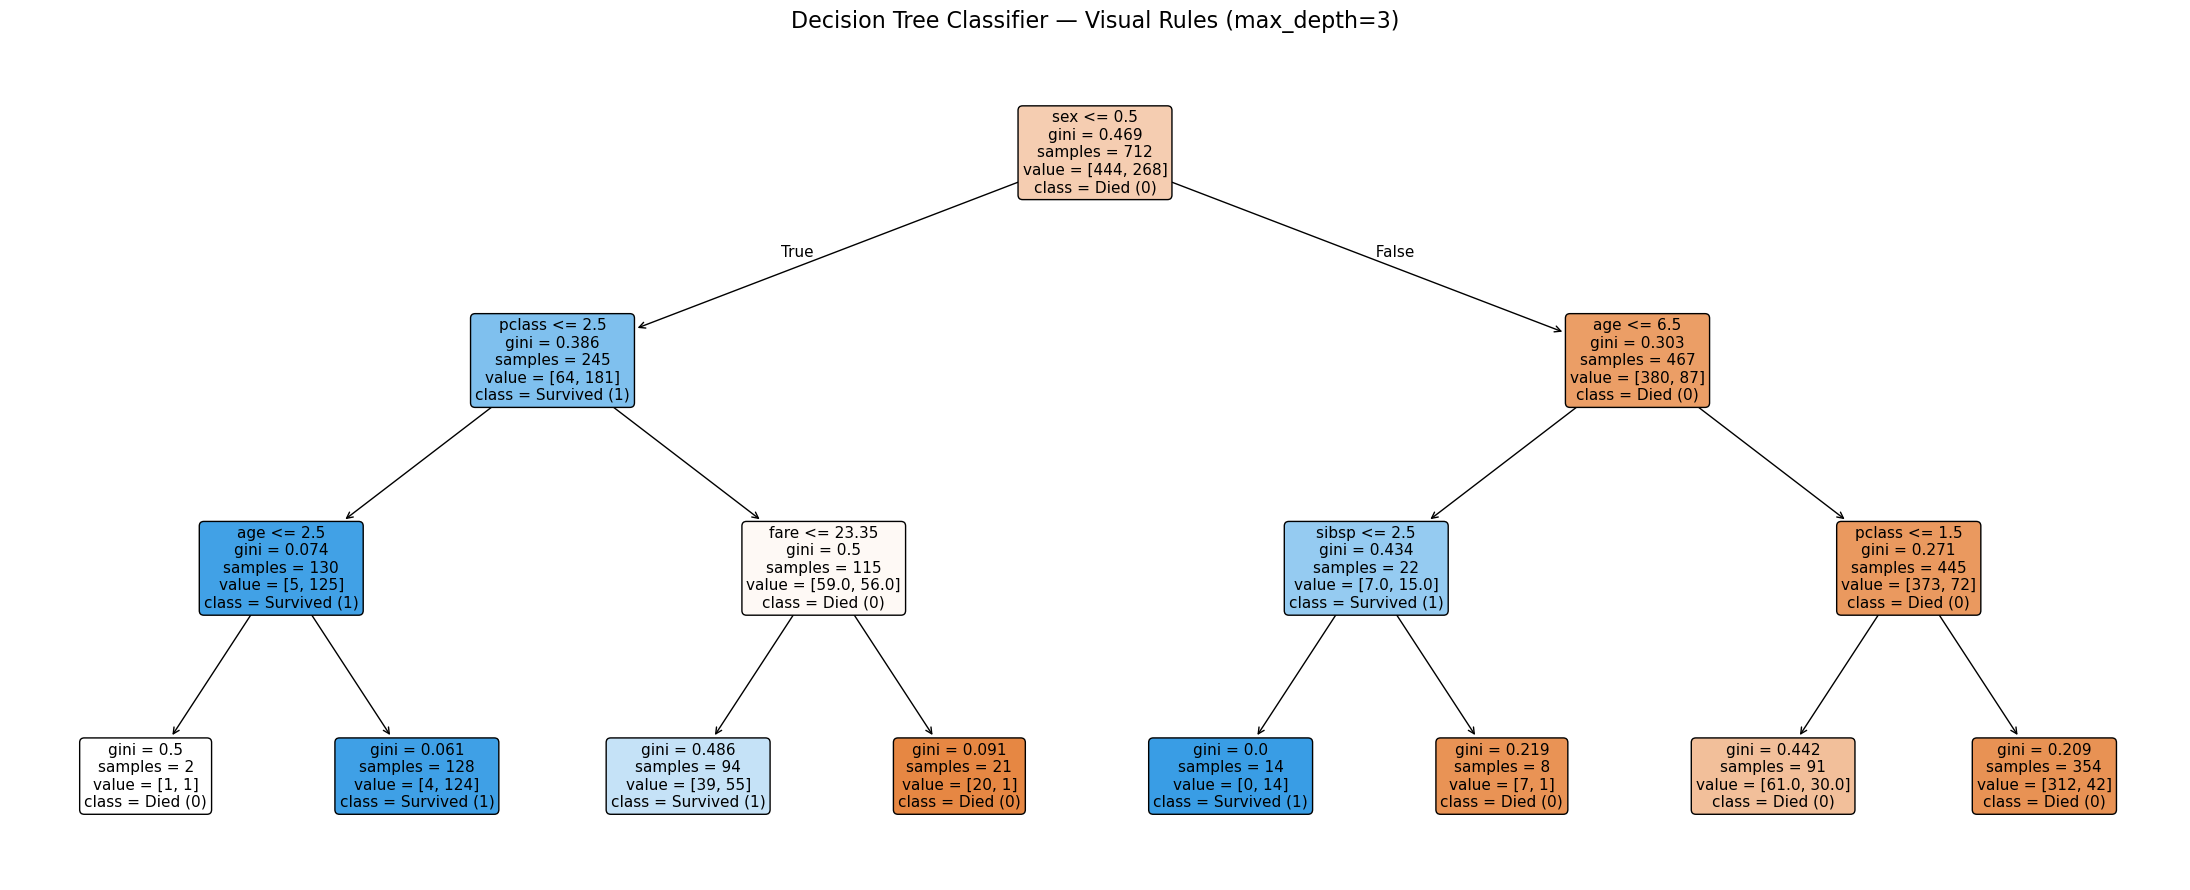


💡 Each node shows: the rule, how many samples, how many of each class, and the majority prediction.
   Blue = predicted Survived, Orange = predicted Died. Darker = more confident.


In [55]:
# Visualize the tree — this is the key demo moment!
plt.figure(figsize=(22, 9))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['Died (0)', 'Survived (1)'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Decision Tree Classifier — Visual Rules (max_depth=3)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()
print('\n💡 Each node shows: the rule, how many samples, how many of each class, and the majority prediction.')
print('   Blue = predicted Survived, Orange = predicted Died. Darker = more confident.')

Classification Report — Decision Tree:
              precision    recall  f1-score   support

        Died       0.80      0.88      0.84       105
    Survived       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



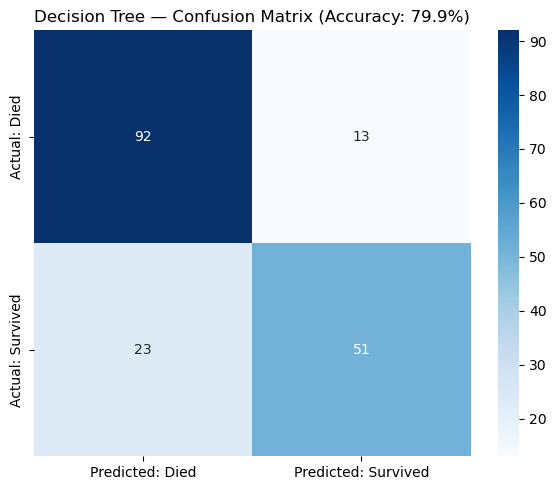


Confusion matrix reading:
  True Negatives (correctly predicted Died):           92
  False Positives (predicted Survived, actually Died): 13
  False Negatives (predicted Died, actually Survived): 23
  True Positives (correctly predicted Survived):       51


In [56]:
# Full evaluation
print('Classification Report — Decision Tree:')
print(classification_report(y_test, y_pred_dt, target_names=['Died', 'Survived']))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title(f'Decision Tree — Confusion Matrix (Accuracy: {acc_dt:.1%})')
plt.tight_layout()
plt.show()
print('\nConfusion matrix reading:')
print(f'  True Negatives (correctly predicted Died):           {cm_dt[0,0]}')
print(f'  False Positives (predicted Survived, actually Died): {cm_dt[0,1]}')
print(f'  False Negatives (predicted Died, actually Survived): {cm_dt[1,0]}')
print(f'  True Positives (correctly predicted Survived):       {cm_dt[1,1]}')

---
## Section 5 — Algorithm 3: K-Nearest Neighbors (KNN)

**Intuition:** Imagine you're a new student at a school. To predict if you'll like the school canteen, ask the 5 most similar students to you — and go with whatever the majority says.

**For Titanic:** To predict if passenger X survived, find the 5 most similar passengers in the training data and use the majority outcome.

**Distance metric:** Euclidean distance across all features (age, fare, pclass, etc.)

In [57]:
# Train KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f'KNN (k=5) Accuracy: {acc_knn:.1%}')
print()
print('How KNN predicts for a new passenger:')
print('  1. Calculate distance from new passenger to ALL training passengers')
print('  2. Find the 5 closest ones')
print('  3. Count how many of those 5 survived vs died')
print('  4. Predict the majority class')
print()
print('💡 k=5 means "ask 5 neighbors" — try different k values to see accuracy change!')

KNN (k=5) Accuracy: 69.3%

How KNN predicts for a new passenger:
  1. Calculate distance from new passenger to ALL training passengers
  2. Find the 5 closest ones
  3. Count how many of those 5 survived vs died
  4. Predict the majority class

💡 k=5 means "ask 5 neighbors" — try different k values to see accuracy change!


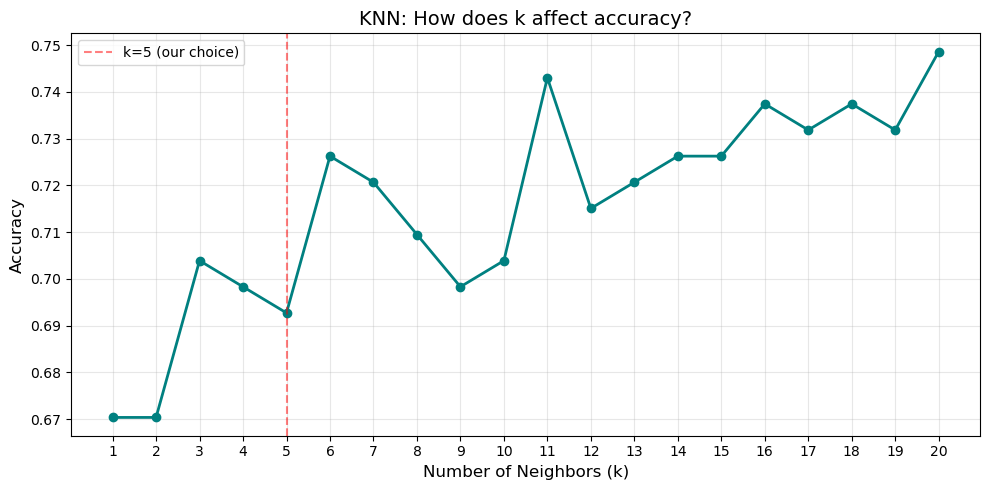


💡 Very small k = overfits (too sensitive to noise)
   Very large k = underfits (too general, ignores local patterns)


In [58]:
# How does k affect accuracy? Let's visualize it
k_values = range(1, 21)
accuracies = [accuracy_score(y_test, KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).predict(X_test))
              for k in k_values]

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='teal', linewidth=2)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='k=5 (our choice)')
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: How does k affect accuracy?', fontsize=14)
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('\n💡 Very small k = overfits (too sensitive to noise)')
print('   Very large k = underfits (too general, ignores local patterns)')

---
## Section 6 — Comparison: All 3 Algorithms

Which algorithm should you use? It depends on your priorities.
Here's a clear comparison across the 3 approaches.

ALGORITHM COMPARISON SUMMARY
              Algorithm Accuracy Designed for classification?   Interpretability            Key Strength                Key Weakness
      Linear Regression    78.2%                         No ❌             Medium         Simple baseline      Predicts outside [0,1]
Decision Tree (depth=3)    79.9%                        Yes ✅ High (visual tree)       Explainable rules Can overfit with deep trees
              KNN (k=5)    69.3%                        Yes ✅                Low No training assumptions      Slow on large datasets


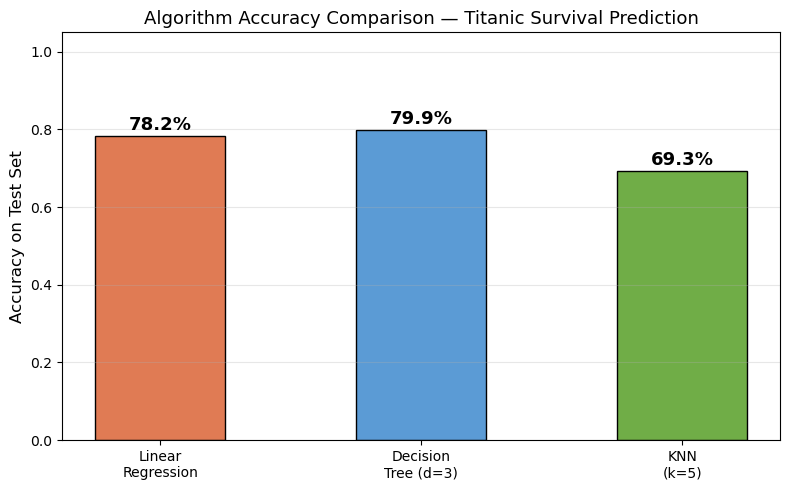

In [59]:
# Comparison table
results = pd.DataFrame({
    'Algorithm': ['Linear Regression', 'Decision Tree (depth=3)', 'KNN (k=5)'],
    'Accuracy': [f'{acc_lr:.1%}', f'{acc_dt:.1%}', f'{acc_knn:.1%}'],
    'Designed for classification?': ['No ❌', 'Yes ✅', 'Yes ✅'],
    'Interpretability': ['Medium', 'High (visual tree)', 'Low'],
    'Key Strength': [
        'Simple baseline',
        'Explainable rules',
        'No training assumptions'
    ],
    'Key Weakness': [
        'Predicts outside [0,1]',
        'Can overfit with deep trees',
        'Slow on large datasets'
    ]
})

print('='*90)
print('ALGORITHM COMPARISON SUMMARY')
print('='*90)
print(results.to_string(index=False))

# Bar chart comparison
accs = [acc_lr, acc_dt, acc_knn]
labels = ['Linear\nRegression', 'Decision\nTree (d=3)', 'KNN\n(k=5)']
colors = ['#e07b54', '#5b9bd5', '#70ad47']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel('Accuracy on Test Set', fontsize=12)
plt.title('Algorithm Accuracy Comparison — Titanic Survival Prediction', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## [Optional] Section 7 — Random Forest

**The voting booth analogy:** Instead of one Decision Tree, grow 100 different trees. Each tree votes on the outcome. The majority wins.

**Why it's better than a single tree:** Each tree sees a random subset of data and features, so they make different errors. When you average many different errors, they cancel out.

> "None of us is as smart as all of us" — that's ensemble learning.

*This section is self-contained — run or skip without affecting earlier sections.*

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest (100 trees) Accuracy: {acc_rf:.1%}')
print(f'Single Decision Tree Accuracy:       {acc_dt:.1%}')
print(f'\n🌲 Random Forest improvement: {acc_rf - acc_dt:+.1%}')

Random Forest (100 trees) Accuracy: 79.9%
Single Decision Tree Accuracy:       79.9%

🌲 Random Forest improvement: +0.0%


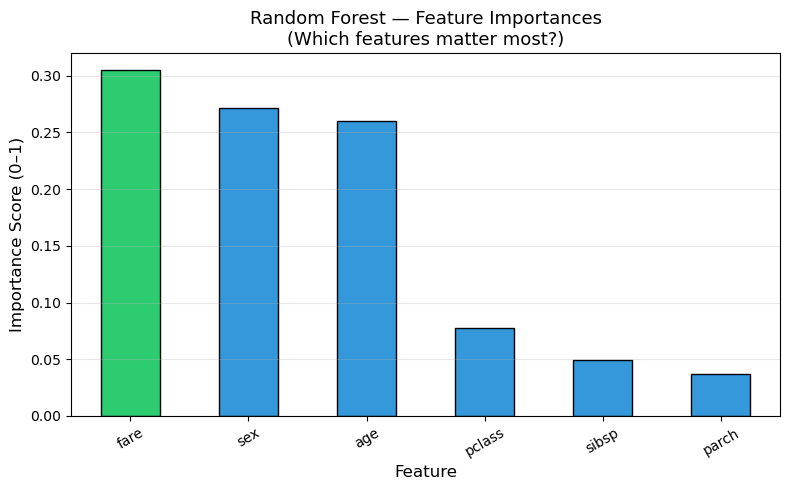


💡 Higher = more important for predicting survival.
   Most important feature: fare (30.5% importance)


In [61]:
# Feature importances — what matters most?
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors_fi = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(feat_imp))]
feat_imp.plot(kind='bar', color=colors_fi, edgecolor='black')
plt.title('Random Forest — Feature Importances\n(Which features matter most?)', fontsize=13)
plt.ylabel('Importance Score (0–1)', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print('\n💡 Higher = more important for predicting survival.')
print(f'   Most important feature: {feat_imp.index[0]} ({feat_imp.iloc[0]:.1%} importance)')

---
## [Optional] Section 8 — Support Vector Machine (SVM)

**The road analogy:** Imagine two groups of dots on a map (survived / died). SVM draws the **widest possible road** between them — the road that keeps the most space from each group.

The boundary is called a **hyperplane**. In 2D it's a line; in many dimensions it's a hyperplane. The width of the road is called the **margin**.

SVM is very powerful but less interpretable — you can't easily see WHY it made a decision.

*This section is self-contained — run or skip without affecting earlier sections.*

In [62]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SVM needs scaled features (StandardScaler centers + normalizes)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=42, max_iter=3000))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f'SVM (Linear) Accuracy: {acc_svm:.1%}')
print()
print('Key SVM concepts:')
print('  • Support Vectors: the data points closest to the boundary (the ones that define it)')
print('  • Margin: the gap between the boundary and the closest points — SVM maximizes this')
print('  • Why scale features? SVM uses distance — without scaling, "fare" (0–500) would')
print('    dominate "pclass" (1–3) purely because of its larger numbers')

SVM (Linear) Accuracy: 79.3%

Key SVM concepts:
  • Support Vectors: the data points closest to the boundary (the ones that define it)
  • Margin: the gap between the boundary and the closest points — SVM maximizes this
  • Why scale features? SVM uses distance — without scaling, "fare" (0–500) would
    dominate "pclass" (1–3) purely because of its larger numbers


In [63]:
# Final comparison — all 5 algorithms
all_results = pd.DataFrame({
    'Algorithm': [
        'Linear Regression',
        'Decision Tree (depth=3)',
        'KNN (k=5)',
        'Random Forest (100 trees)',
        'SVM (Linear)'
    ],
    'Accuracy': [
        f'{acc_lr:.1%}',
        f'{acc_dt:.1%}',
        f'{acc_knn:.1%}',
        f'{acc_rf:.1%}',
        f'{acc_svm:.1%}'
    ],
    'Type': ['Regression', 'Classification', 'Classification', 'Ensemble', 'Classification'],
    'Interpretability': ['Medium', 'High', 'Low', 'Medium', 'Low']
})

print('='*70)
print('COMPLETE ALGORITHM COMPARISON')
print('='*70)
print(all_results.to_string(index=False))
print()
print('✅ Pipeline complete! You have now implemented 5 ML approaches on the same dataset.')

COMPLETE ALGORITHM COMPARISON
                Algorithm Accuracy           Type Interpretability
        Linear Regression    78.2%     Regression           Medium
  Decision Tree (depth=3)    79.9% Classification             High
                KNN (k=5)    69.3% Classification              Low
Random Forest (100 trees)    79.9%       Ensemble           Medium
             SVM (Linear)    79.3% Classification              Low

✅ Pipeline complete! You have now implemented 5 ML approaches on the same dataset.
